# Ex - 

### Introduction:

This time you will create a data 

Special thanks to: https://github.com/justmarkham for sharing the dataset and materials.

### Step 1. Import the necessary libraries

In [4]:

import pandas as pd

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv). 

### Step 3. Assign it to a variable called 

In [9]:
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv'
df = pd.read_csv(url, sep ="\t")
df.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


### Step 4. 

In [10]:
df.tail()

,order_id,quantity,item_name,choice_description,item_price
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75
4621,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$8.75


### Step 5. 

In [13]:
df.shape[1]

5

### Step 6. 

In [14]:
df.columns

Index(['order_id', 'quantity', 'item_name', 'choice_description',
       'item_price'],
      dtype='object')

### Step 7. 

In [15]:
df.index

RangeIndex(start=0, stop=4622, step=1)

### Step 8. 

In [16]:
most_ordered = df.groupby('item_name')['quantity'].sum().sort_values(ascending=False)
most_ordered.head(1)

item_name
Chicken Bowl    761
Name: quantity, dtype: int64

### Step 9. 

In [17]:
most_ordered.iloc[0]

np.int64(761)

### Step 10. 

In [18]:
most_ordered_choice = df.groupby('choice_description')['quantity'].sum().sort_values(ascending=False)
most_ordered_choice.head(1)

choice_description
[Diet Coke]    159
Name: quantity, dtype: int64

### Step 11. 

In [19]:
total_items = df['quantity'].sum()
print(total_items)

4972


### Step 12. 

In [ ]:
if df.item_price.dtype == 'O':
    df['item_price'] = df['item_price'].str.replace('$', '', regex=False).astype(float)

# Check the type to confirm
print(df.item_price.dtype)


float64


### Step 13. 

In [21]:
revenue = (df['quantity'] * df['item_price']).sum()
print('Revenue was: $' + str(round(revenue, 2)))

Revenue was: $39237.02


### Step 14. 

In [22]:
orders = df.order_id.nunique()
print(orders)

1834


### Step 15. 

In [23]:
df['revenue'] = df['quantity'] * df['item_price']
order_grouped = df.groupby(by=['order_id']).sum(numeric_only=True)

# Then take the mean of the revenue
mean_revenue = order_grouped['revenue'].mean()
print(mean_revenue)

21.39423118865867


### Step 16. 

In [24]:
df.item_name.nunique()

50

### BONUS: Create your own question and answer it.

C:\Users\Dani_\AppData\Local\Temp\ipykernel_22884\3630647795.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_items.values, y=top_items.index, ax=axes[0, 0], palette='viridis')
C:\Users\Dani_\AppData\Local\Temp\ipykernel_22884\3630647795.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_revenue.values, y=top_revenue.index, ax=axes[0, 1], palette='magma')


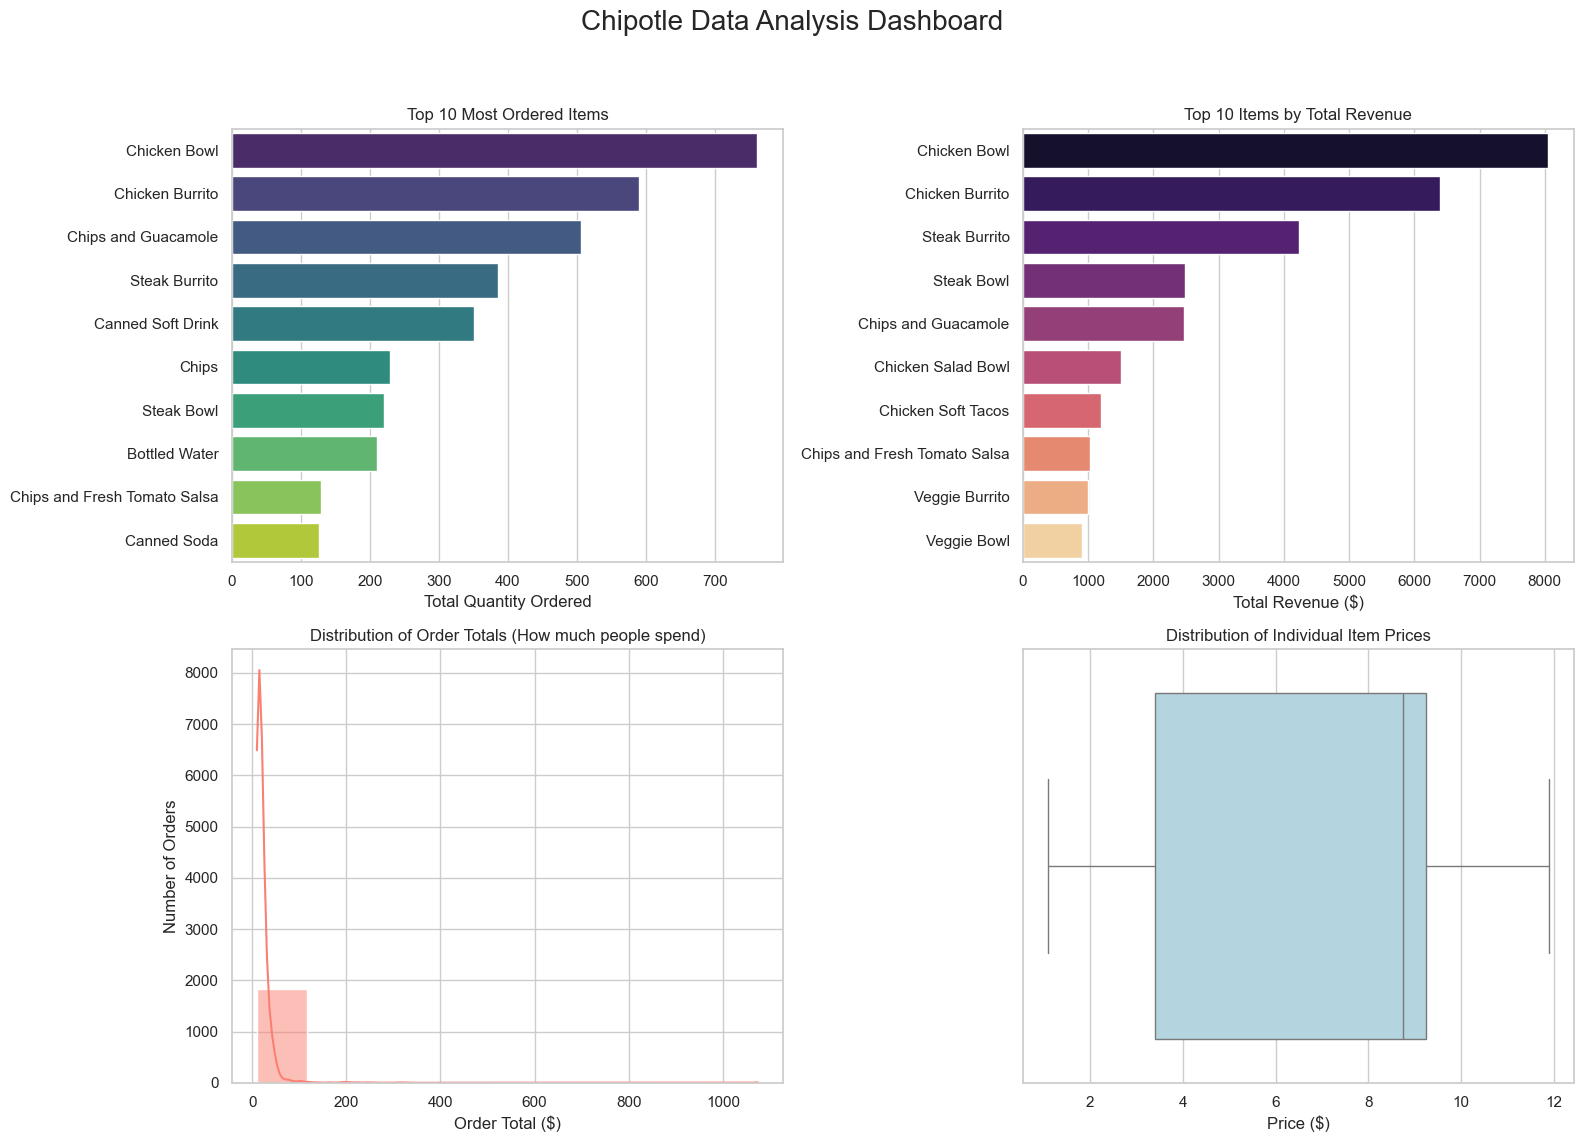

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Chipotle Data Analysis Dashboard', fontsize=20)

# Plot 1: Top 10 Most Ordered Items (Bar Chart)

top_items = df.groupby('item_name')['quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_items.values, y=top_items.index, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Top 10 Most Ordered Items')
axes[0, 0].set_xlabel('Total Quantity Ordered')
axes[0, 0].set_ylabel('')

# Plot 2: Top 10 Items by Total Revenue (Bar Chart)

df['revenue'] = df['quantity'] * df['item_price']
top_revenue = df.groupby('item_name')['revenue'].sum().sort_values(ascending=False).head(10)

sns.barplot(x=top_revenue.values, y=top_revenue.index, ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Top 10 Items by Total Revenue')
axes[0, 1].set_xlabel('Total Revenue ($)')
axes[0, 1].set_ylabel('')


# Plot 3: Distribution of Order Total Prices (Histogram)

order_totals = df.groupby('order_id')['revenue'].sum()
sns.histplot(order_totals, bins=10, kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Distribution of Order Totals (How much people spend)')
axes[1, 0].set_xlabel('Order Total ($)')
axes[1, 0].set_ylabel('Number of Orders')


# Plot 4: Item Price Distribution (Box Plot)

unit_prices = df[df['quantity'] == 1]
sns.boxplot(x='item_price', data=unit_prices, ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title('Distribution of Individual Item Prices')
axes[1, 1].set_xlabel('Price ($)')

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()